## Mount google drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Libraries

In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import time
from tqdm import tqdm


## Create/Load Dataframe

In [3]:


# cartella su Google Drive
base_path = "/content/drive/MyDrive/MLHD_Project/experiment-i"

# Dizionario
dataset = {}

# Itero su tutte le cartelle S1->S13
for subject in tqdm(range(1, 14)):
    subject_id = f"S{subject}"
    subject_path = os.path.join(base_path, subject_id)

    #per sicurezza
    if not os.path.exists(subject_path):
        print(f"Cartella {subject_id} non trovata, la salto.")
        continue

    dataset[subject_id] = []

    # Ottengo la lista dei file nella cartella
    files = sorted([f for f in os.listdir(subject_path) if f.endswith(".txt")], key=lambda x: int(x.split(".")[0]))

    # Itero sui file della cartella soggetto
    for file_name in files:
        file_path = os.path.join(subject_path, file_name)

        try:
            # Carico i dati riga per riga
            data = np.loadtxt(file_path)
        #per sicurezza
        except Exception as e:
            print(f"Errore nella lettura di {file_path}: {e}")
            continue

        # Ogni riga è un'osservazione che va convertita in una matrice 64x32
        num_observations = data.shape[0]  # Numero di righe = numero di osservazioni
        try:
            matrices = data.reshape(num_observations, 64, 32)
            #matrices = matrices/1000 #normalize (min and max values are 0 and 1000)
        #per sicurezza
        except ValueError as e:
            print(f"Errore nel reshape del file {file_path}: {e}")
            continue

        # Salvo nel dizionario
        dataset[subject_id].append(matrices)

# Converto in un DataFrame per una gestione più semplice
df = pd.DataFrame([
    {"subject": subj, "observation": obs, "data": matrices}
    for subj, obs_list in dataset.items()
    for obs, matrices in enumerate(obs_list, start=1)
])



# Visualizzo le prime righe
print(df.head())



100%|██████████| 13/13 [00:09<00:00,  1.41it/s]


  subject  observation                                               data
0      S1            1  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
1      S1            2  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
2      S1            3  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
3      S1            4  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
4      S1            5  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...


In [4]:
#normalizzo
g_min = 0
g_max = 0
for i in tqdm(range(len(df))):
    a = np.max(df["data"][i])
    if a > g_max:
        g_max = a
    b = np.min(df["data"][i])
    if b < g_min:
        g_min = b

for i in tqdm(range(len(df))):
    df["data"][i] = (df["data"][i] - g_min) / (g_max - g_min)

  0%|          | 0/221 [00:00<?, ?it/s]/tmp/ipython-input-3587768813.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["data"][i] = (df["data"][i] - g_min) / (g_max - g_min)
/tmp/ipython-input-3587768813.py:13: SettingWithCopyWarning: 

In [ ]:
#df.to_pickle("dataset.pkl") # save df - preserves the structure of the datafram

In [ ]:
#df = pd.read_pickle("dataset.pkl")
#type(df) #pd.DataFrame as it was


In [5]:
a = 0
for i in range(len(df)):
  b = np.min(df['data'][i])
  if b > a:
    a = b
print(a)

a = 0
for i in range(len(df)):
  b = np.max(df['data'][i])
  if b > a:
    a = b
print(a)

0
1.0


## The DataFrame

In [ ]:
#Seleziono tutte le osservazioni di un soggetto
subject_data = df[df["subject"] == "S1"]
print(subject_data)

   subject  observation                                               data
0       S1            1  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
1       S1            2  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
2       S1            3  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
3       S1            4  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
4       S1            5  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
5       S1            6  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
6       S1            7  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
7       S1            8  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
8       S1            9  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
9       S1           10  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
10      S1           11  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
11      S1           12  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
12      S1           13  

In [ ]:
#dati di una osservazione
observation = subject_data[subject_data["observation"] == 1]["data"].values[0]
print(observation.shape)  # Dovrebbe restituire (num_observazioni, 64, 32)

(82, 64, 32)


In [ ]:
print(df)

    subject  observation                                               data
0        S1            1  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
1        S1            2  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
2        S1            3  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
3        S1            4  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
4        S1            5  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
..      ...          ...                                                ...
216     S13           13  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
217     S13           14  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
218     S13           15  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
219     S13           16  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...
220     S13           17  [[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...

[221 rows x 3 columns]


## Create X and y


In [6]:
#ho una matrice con la pressione di una persona buttata su un materassino

# Preparo data and labels per CNN

all_data = []
all_labels = []

#assegno ad ogni matrice all'interno dello stesso file la stessa label, perchè per ogni
#posizione ho diverse osservazioni che avranno tutte bisogno della stessa label

for index, row in df.iterrows():
    matrices = row['data']
    label = row['observation'] - 1
    # Use the observation number as the label, subtracting 1 to make it 0-indexed
    num_observations_in_file = matrices.shape[0]
    for i in range(num_observations_in_file):
        global_index = index * num_observations_in_file + i # Calculate the global index
        all_data.append(matrices[i, :, :])
        # All matrices within the same file (same observation number) have the same label
        all_labels.append(label)

X = np.array(all_data)
y = np.array(all_labels)

# Reshape the data per includere una channel dimension (grayscale images)
X = X.reshape(X.shape[0], 64, 32, 1)



## Visualize data samples

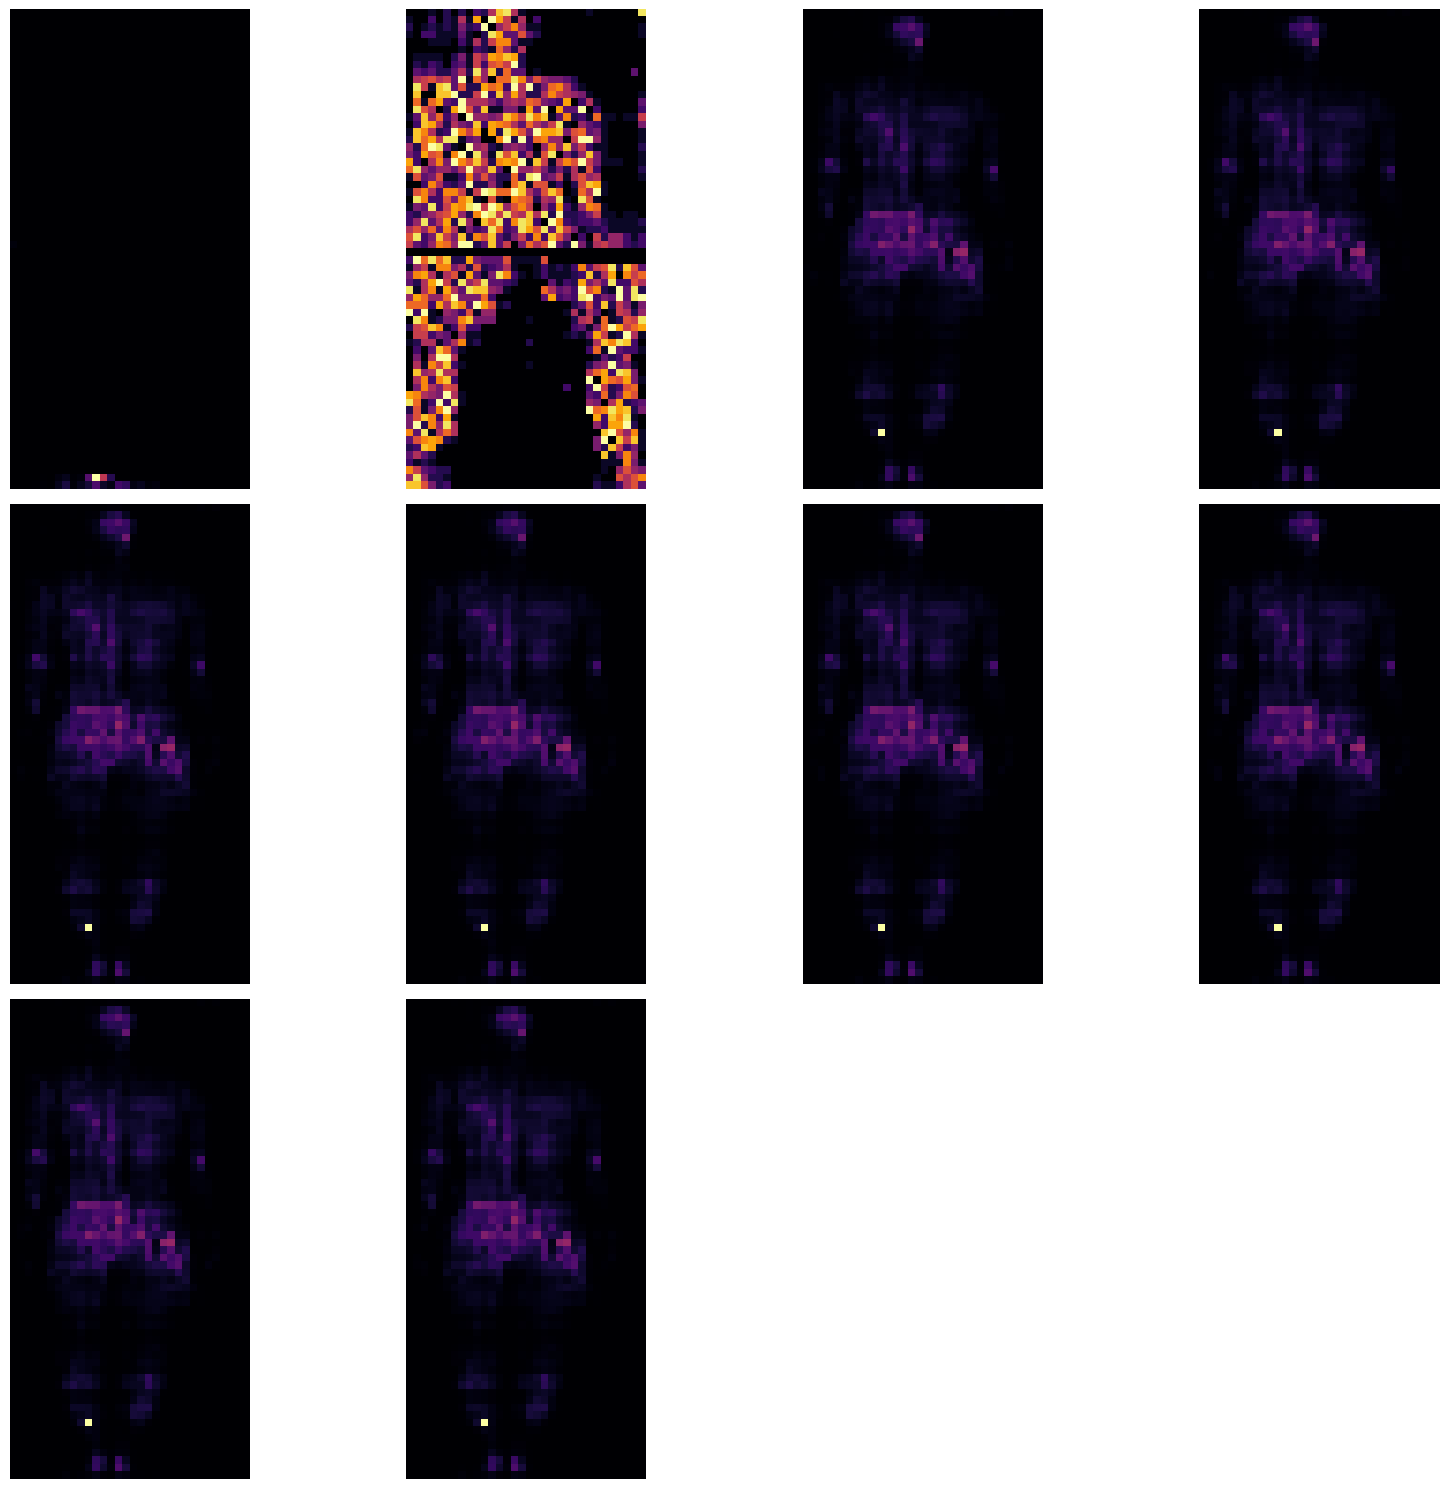

In [7]:
num_to_visualize = 10

# Calculate the number of rows and columns for subplots
n_cols = 4
n_rows = (num_to_visualize + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 4, n_rows * 5)) # Adjust figure size based on number of subplots

for i in range(num_to_visualize):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(X[i, :, :, 0], cmap='inferno')#cmap='gray' per il bianco e nero
    plt.axis('off')

plt.tight_layout()
plt.show()


## Sensor detection errors

In [25]:
# Prompt: Trova gli indici delle immagini con oltre il 80% di pixel = 0 (pre-modello)
zero_pixel_threshold = 0.8  # 80%
highly_zero_input_indices = []
highly_zero_input_count = 0

for idx in range(len(X)):
    image = X[idx, :, :, 0]  # immagine in scala di grigi
    total_pixels = image.size
    zero_pixels = np.sum(image == 0)
    zero_pixel_ratio = zero_pixels / total_pixels

    if zero_pixel_ratio >= zero_pixel_threshold:
        highly_zero_input_count += 1
        highly_zero_input_indices.append(idx)

print(f"\nNumber of input samples with over {zero_pixel_threshold * 100:.0f}% zero pixels: {highly_zero_input_count}")
print(f"Indices of these samples: {highly_zero_input_indices}")


# Count input samples with over 10% high pixels and save their indices
high_pixel_threshold = 0.10  # 10%
highly_high_input_indices = []
highly_high_input_count = 0

for idx in range(len(X)):
    image = X[idx, :, :, 0] # Get the grayscale image
    total_pixels = image.size
    zero_pixels = np.sum(image > 0.30)
    zero_pixel_ratio = zero_pixels / total_pixels

    if zero_pixel_ratio >= high_pixel_threshold:
        highly_high_input_count += 1
        highly_high_input_indices.append(idx)

print(f"\nNumber of input samples with over {high_pixel_threshold*100}% high pixels: {highly_high_input_count}")
print(f"Indices of these samples: {highly_high_input_indices}")


Number of input samples with over 80% zero pixels: 222
Indices of these samples: [0, 82, 152, 242, 311, 389, 458, 599, 673, 746, 826, 901, 982, 1058, 1151, 1232, 1322, 1410, 1477, 1549, 1618, 1702, 1771, 1843, 1918, 1998, 2073, 2142, 2214, 2286, 2356, 2426, 2492, 2558, 2637, 2718, 2796, 2869, 2950, 3023, 3116, 3211, 3294, 3368, 3449, 3529, 3605, 3685, 3763, 3836, 3903, 3982, 4052, 4141, 4227, 4302, 4364, 4448, 4519, 4591, 4661, 4748, 4825, 4893, 4975, 5054, 5128, 5204, 5305, 5423, 5546, 5676, 5802, 5921, 6042, 6168, 6295, 6425, 6555, 6679, 6805, 6928, 7042, 7160, 7270, 7280, 7377, 7446, 7524, 7607, 7679, 7757, 7830, 7904, 7975, 8046, 8119, 8194, 8266, 8267, 8340, 8409, 8486, 8551, 8710, 8865, 9000, 9141, 9286, 9426, 9564, 9775, 9898, 10044, 10186, 10321, 10464, 10597, 10729, 10854, 10978, 11097, 11213, 11326, 11443, 11584, 11710, 11859, 11973, 12096, 12209, 12344, 12456, 12570, 12677, 12788, 12900, 13028, 13098, 13166, 13230, 13311, 13416, 13482, 13553, 13624, 13697, 13765, 13839, 139

## Remove sensor detetion errors


In [26]:
import numpy as np

# Creo una maschera booleana che è True per tutti i campioni NON da rimuovere
# Unisco gli indici da rimuovere
indices_to_remove = list(set(highly_high_input_indices + highly_zero_input_indices))

# Creo la maschera: True = da tenere, False = da rimuovere
mask = np.ones(len(X), dtype=bool)
mask[indices_to_remove] = False

# Applico la maschera a X
X_cleaned = X[mask]
y_cleaned = y[mask]

# Riconversione delle etichette in one-hot, dopo il filtraggio
#y_cleaned_categorical = to_categorical(y_cleaned, num_classes=num_classes)
# Convert labels to categorical (one-hot encoding)
num_classes = len(np.unique(y_cleaned)) #17
print(num_classes)
y_categorical = to_categorical(y_cleaned, num_classes=num_classes)


17



Number of removed samples from input set: 446

Visualizing some removed samples:


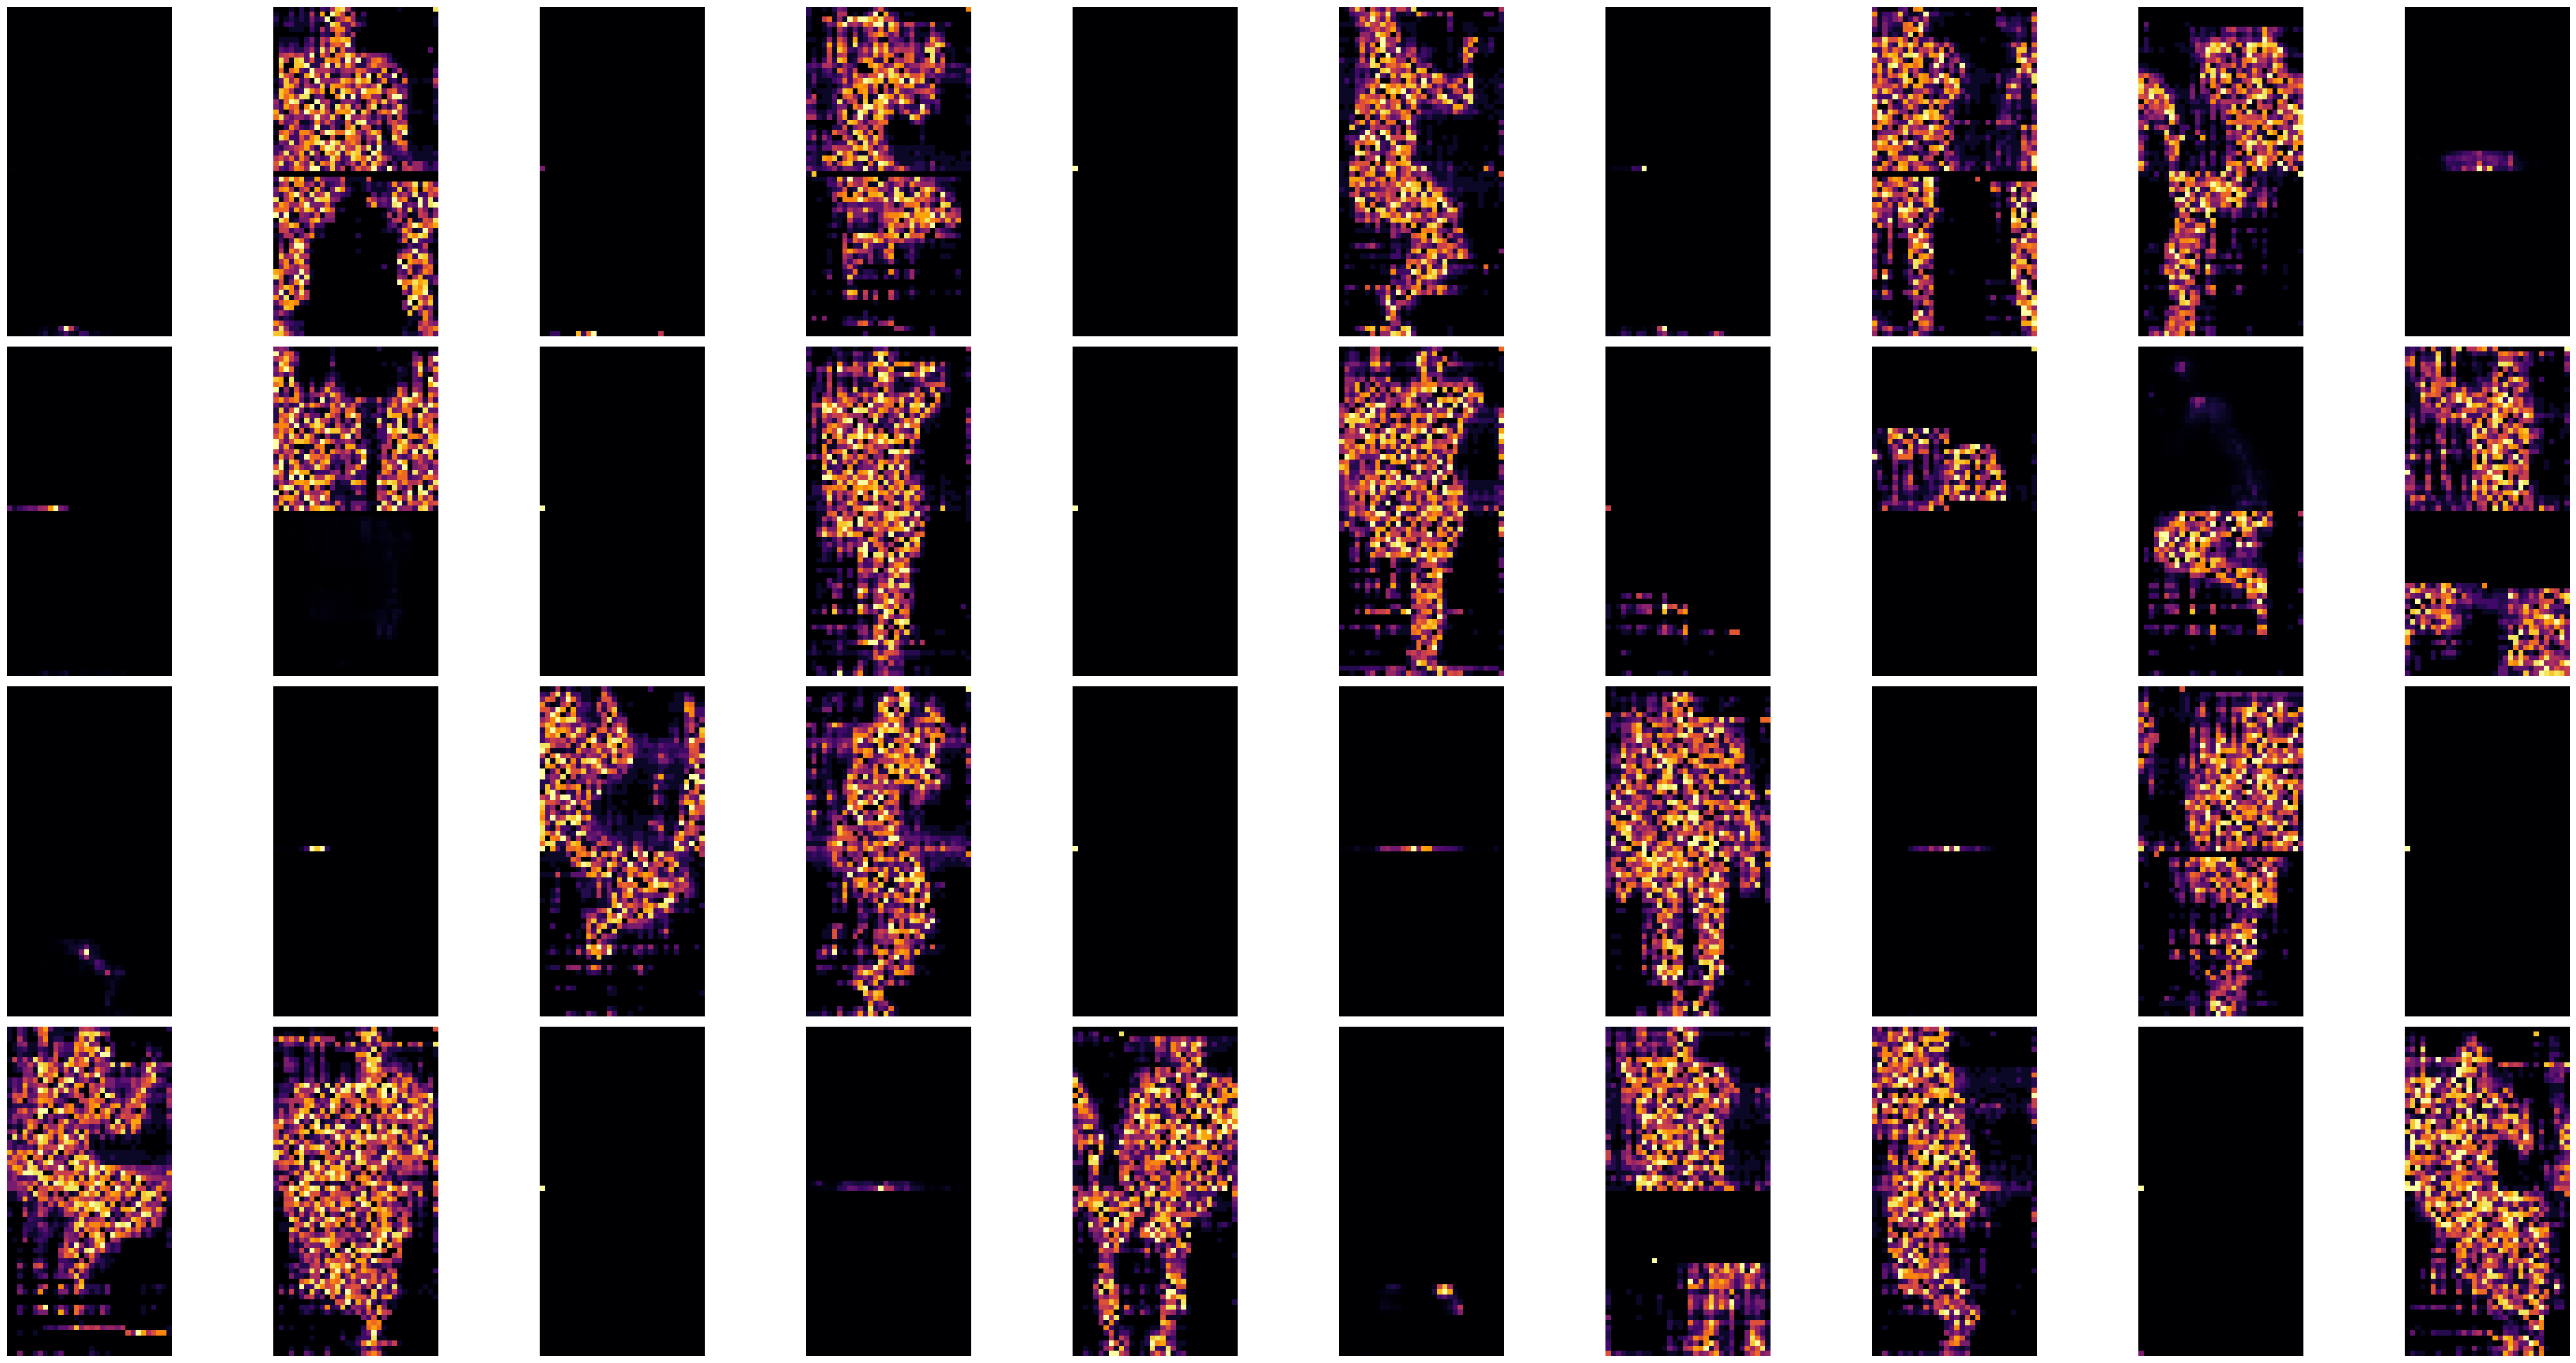

In [27]:

print(f"\nNumber of removed samples from input set: {len(indices_to_remove)}")

# visualize some of the misclassified samples
if len(indices_to_remove) > 0:
    print("\nVisualizing some removed samples:")
    num_to_visualize = min(40, len(indices_to_remove)) # Visualize up to 40 misclassified samples

    # Calculate the number of rows and columns for subplots
    n_cols = 10
    n_rows = (num_to_visualize + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 4, n_rows * 5)) # Adjust figure size based on number of subplots

    for i in range(num_to_visualize):
        index_in_test_set = indices_to_remove[i]
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(X[index_in_test_set, :, :, 0], cmap='inferno')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [28]:
print("Dimensioni originali:", X.shape, y.shape)
print("Campioni rimossi:", len(indices_to_remove))
print("Nuove dimensioni:", X_cleaned.shape, y_cleaned.shape)


Dimensioni originali: (20024, 64, 32, 1) (20024,)
Campioni rimossi: 446
Nuove dimensioni: (19578, 64, 32, 1) (19578,)


## Train - Val - Test Split

In [29]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_categorical, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


## Class distributions on the three sets

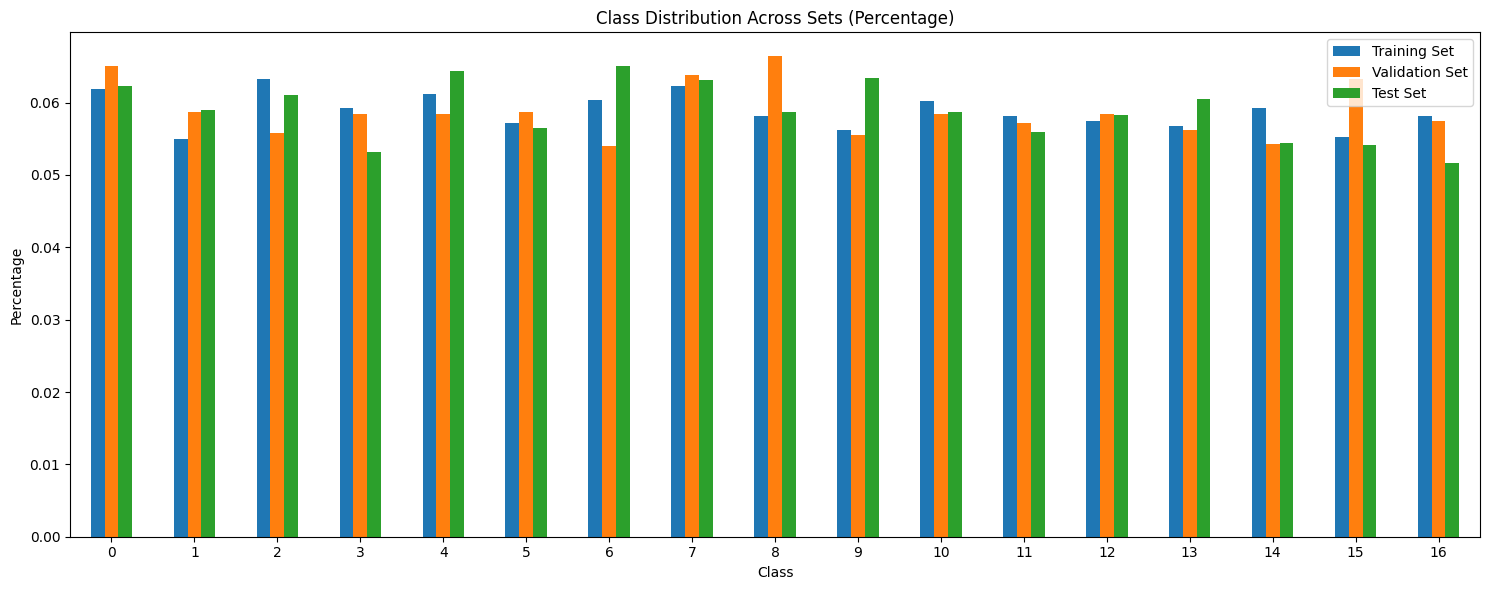

In [30]:
# Function to get original class labels from one-hot encoded labels
def get_original_labels(categorical_labels):
  return np.argmax(categorical_labels, axis=1)

# Get original labels for train, validation, and test sets
y_train_original = get_original_labels(y_train)

# The validation set is the last part of the training data after the split
y_val_original = get_original_labels(y_val)

y_test_original = get_original_labels(y_test)

# Count class occurrences
train_class_counts = pd.Series(y_train_original).value_counts(normalize=True).sort_index()
val_class_counts = pd.Series(y_val_original).value_counts(normalize=True).sort_index()
test_class_counts = pd.Series(y_test_original).value_counts(normalize=True).sort_index()

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Training Set': train_class_counts,
    'Validation Set': val_class_counts,
    'Test Set': test_class_counts
})

# Plotting the distributions
plot_df.plot(kind='bar', figsize=(15, 6))
plt.title('Class Distribution Across Sets (Percentage)')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.legend(loc='upper right')
plt.show()

## Models

### some models i tried

In [ ]:

#model
model_e = Sequential([
    #padding='valid' -> input (30, 62, 32) causa 32-3+1, 64-3+1 con 3 dimensione filtro
    #tutta la cornice viene scartata e non analizzata come centro del filtro 3*3
    Conv2D(16, (3, 3), activation='relu', input_shape=(64, 32, 1)),#<--- padding valid
    MaxPooling2D((3, 3)),#<---
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_e.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Architettura del modello:")
model_e.summary()

train_start_time = time.time()

# Train the model
history = model_e.fit(X_train, y_train, epochs=20, validation_split=0.2, batch_size=32)

train_end_time = time.time()
training_time = train_end_time - train_start_time

# Evaluate the model on the test set
loss, accuracy = model_e.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print(f"Training time: {training_time} seconds")


Architettura del modello:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 30, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 8, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,753 (143.57 KB)

 Trainable params: 36,753 (143.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.2308 - loss: 8.7855 - val_accuracy: 0.7817 - val_loss: 0.7966
Epoch 2/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5694 - loss: 1.2082 - val_accuracy: 0.9326 - val_loss: 0.2925
Epoch 3/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7059 - loss: 0.8032 - val_accuracy: 0.9749 - val_loss: 0.1176
Epoch 4/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7723 - loss: 0.6377 - val_accuracy: 0.9892 - val_loss: 0.0646
Epoch 5/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8460 - loss: 0.4237 - val_accuracy: 0.9900 - val_loss: 0.0293
Epoch 6/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8883 - loss: 0.3068 - val_accuracy: 0.9980 - val_loss: 0.0138
Epoch 7/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9016 - loss: 0.2710 - val_accuracy: 0.9916 - val_loss: 0.0217
Epoch 8/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9147 - loss: 0.2451 - val_accuracy: 0

In [ ]:

#model
model_e = Sequential([
    #padding='valid' -> input (30, 62, 32) causa 32-3+1, 64-3+1 con 3 dimensione filtro
    #tutta la cornice viene scartata e non analizzata come centro del filtro 3*3
    Conv2D(64, (3, 3), activation='relu', input_shape=(64, 32, 1)),#<--- padding valid
    MaxPooling2D((3, 3)),#<---
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_e.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Architettura del modello:")
model_e.summary()

train_start_time = time.time()

# Train the model
history = model_e.fit(X_train, y_train, epochs=20, validation_split=0.2, batch_size=32)

train_end_time = time.time()
training_time = train_end_time - train_start_time

# Evaluate the model on the test set
loss, accuracy = model_e.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print(f"Training time: {training_time} seconds")


Architettura del modello:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 30, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 18, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,289 (1.79 MB)

 Trainable params: 470,289 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.3116 - loss: 6.2393 - val_accuracy: 0.8787 - val_loss: 0.4291
Epoch 2/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7250 - loss: 0.7737 - val_accuracy: 0.9773 - val_loss: 0.0884
Epoch 3/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8555 - loss: 0.4169 - val_accuracy: 0.9916 - val_loss: 0.0412
Epoch 4/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8984 - loss: 0.2777 - val_accuracy: 0.9956 - val_loss: 0.0262
Epoch 5/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9405 - loss: 0.1977 - val_accuracy: 0.9904 - val_loss: 0.0289
Epoch 6/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9541 - loss: 0.1541 - val_accuracy: 0.9904 - val_loss: 0.0376
Epoch 7/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9597 - loss: 0.1648 - val_accuracy: 0.9920 - val_loss: 0.0142
Epoch 8/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9783 - loss: 0.0700 - val_accuracy: 

In [ ]:

#model
model_e = Sequential([
    #padding='valid' -> input (30, 62, 32) causa 32-3+1, 64-3+1 con 3 dimensione filtro
    #tutta la cornice viene scartata e non analizzata come centro del filtro 3*3
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 32, 1)),#<--- padding valid
    MaxPooling2D((2, 2)),#<---
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_e.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Architettura del modello:")
model_e.summary()

train_start_time = time.time()

# Train the model
history = model_e.fit(X_train, y_train, epochs=20, validation_split=0.2, batch_size=32)

train_end_time = time.time()
training_time = train_end_time - train_start_time

# Evaluate the model on the test set
loss, accuracy = model_e.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print(f"Training time: {training_time} seconds")


Architettura del modello:


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_63 (Conv2D)              │ (None, 62, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 31, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 29, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 14, 6, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 12, 4, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 6, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,601 (1.11 MB)

 Trainable params: 291,601 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.3484 - loss: 5.8234 - val_accuracy: 0.9433 - val_loss: 0.2877
Epoch 2/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7421 - loss: 0.6948 - val_accuracy: 0.9597 - val_loss: 0.0988
Epoch 3/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8304 - loss: 0.4451 - val_accuracy: 0.9773 - val_loss: 0.0494
Epoch 4/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8908 - loss: 0.2877 - val_accuracy: 0.9824 - val_loss: 0.0408
Epoch 5/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9151 - loss: 0.2260 - val_accuracy: 0.9808 - val_loss: 0.0292
Epoch 6/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9245 - loss: 0.2136 - val_accuracy: 0.9996 - val_loss: 0.0084
Epoch 7/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9568 - loss: 0.1285 - val_accuracy: 0.9960 - val_loss: 0.0231
Epoch 8/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9633 - loss: 0.1039 - val_accuracy: 0

In [ ]:

#model
model_c = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 32, 1)),
    MaxPooling2D((2, 2)), #<----
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_c.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Architettura del modello:")
model_c.summary()

train_start_time = time.time()

# Train the model
history = model_c.fit(X_train, y_train, epochs=20, validation_split=0.2, batch_size=32)

train_end_time = time.time()
training_time = train_end_time - train_start_time

# Evaluate the model on the test set
loss, accuracy = model_c.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print(f"Training time: {training_time} seconds")

Architettura del modello:


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)              │ (None, 64, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 32, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 16, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 16, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 8, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,281 (2.36 MB)

 Trainable params: 619,281 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.4318 - loss: 4.7344 - val_accuracy: 0.9457 - val_loss: 0.1474
Epoch 2/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8004 - loss: 0.5435 - val_accuracy: 0.9940 - val_loss: 0.0643
Epoch 3/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8415 - loss: 0.4407 - val_accuracy: 0.9960 - val_loss: 0.0361
Epoch 4/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8927 - loss: 0.3116 - val_accuracy: 0.9948 - val_loss: 0.0281
Epoch 5/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9171 - loss: 0.2442 - val_accuracy: 0.9988 - val_loss: 0.0234
Epoch 6/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9171 - loss: 0.2540 - val_accuracy: 0.9932 - val_loss: 0.0245
Epoch 7/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9386 - loss: 0.1835 - val_accuracy: 0.9948 - val_loss: 0.0197
Epoch 8/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9385 - loss: 0.1890 - val_accuracy: 

#### model first pooling 4*4

In [ ]:

#model
model_c = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 32, 1)),
    MaxPooling2D((4, 4)), #<----
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_c.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Architettura del modello:")
model_c.summary()

train_start_time = time.time()

# Train the model
history = model_c.fit(X_train, y_train, epochs=20, validation_split=0.2, batch_size=32)

train_end_time = time.time()
training_time = train_end_time - train_start_time

# Evaluate the model on the test set
loss, accuracy = model_c.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print(f"Training time: {training_time} seconds")

Architettura del modello:


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 64, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 16, 8, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 16, 8, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 8, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 8, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,065 (883.07 KB)

 Trainable params: 226,065 (883.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.2136 - loss: 8.0089 - val_accuracy: 0.6987 - val_loss: 1.0674
Epoch 2/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4491 - loss: 1.5535 - val_accuracy: 0.8667 - val_loss: 0.6075
Epoch 3/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6068 - loss: 1.1296 - val_accuracy: 0.9769 - val_loss: 0.1680
Epoch 4/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7500 - loss: 0.6784 - val_accuracy: 0.9952 - val_loss: 0.0408
Epoch 5/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8309 - loss: 0.4766 - val_accuracy: 0.9992 - val_loss: 0.0149
Epoch 6/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9031 - loss: 0.2595 - val_accuracy: 0.9876 - val_loss: 0.0216
Epoch 7/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9401 - loss: 0.1630 - val_accuracy: 0.9880 - val_loss: 0.0374
Epoch 8/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9458 - loss: 0.1522 - val_accuracy: 

In [ ]:

#model
model_c = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 32, 1)),
    MaxPooling2D((3, 3)), #<----
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_c.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Architettura del modello:")
model_c.summary()

train_start_time = time.time()

# Train the model
history = model_c.fit(X_train, y_train, epochs=20, validation_split=0.2, batch_size=32)

train_end_time = time.time()
training_time = train_end_time - train_start_time

# Evaluate the model on the test set
loss, accuracy = model_c.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print(f"Training time: {training_time} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Architettura del modello:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 21, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 5, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 5, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,833 (1011.07 KB)

 Trainable params: 258,833 (1011.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3055 - loss: 6.5584 - val_accuracy: 0.9282 - val_loss: 0.3602
Epoch 2/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6930 - loss: 0.8316 - val_accuracy: 0.9848 - val_loss: 0.0995
Epoch 3/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7755 - loss: 0.5837 - val_accuracy: 0.9936 - val_loss: 0.0449
Epoch 4/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8433 - loss: 0.4083 - val_accuracy: 0.9832 - val_loss: 0.0349
Epoch 5/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8718 - loss: 0.3260 - val_accuracy: 0.9836 - val_loss: 0.0452
Epoch 6/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8973 - loss: 0.2822 - val_accuracy: 0.9661 - val_loss: 0.0635
Epoch 7/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9203 - loss: 0.2127 - val_accuracy: 0.9924 - val_loss: 0.0303
Epoch 8/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9286 - loss: 0.2036 - val_accuracy: 

### final model

#### model padding valid and first pooling 3*3



In [31]:

#model
model_fi = Sequential([
    #padding='valid' -> input (30, 62, 32) causa 32-3+1, 64-3+1 con 3 dimensione filtro
    #tutta la cornice viene scartata e non analizzata come centro del filtro 3*3
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 32, 1)),#<--- padding valid
    MaxPooling2D((3, 3)),#<---
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_fi.compile(optimizer='adam', #default lr=0.001 but then is adaptive
              loss='categorical_crossentropy',
              metrics=['accuracy'])
#Adam adapts the effective step size per parameter using estimates
#of first and second moments of the gradients.

print("Architettura del modello:")
model_fi.summary()

train_start_time = time.time()

# Train the model
history = model_fi.fit(X_train, y_train, epochs=20, validation_split=0.2, batch_size=32)

train_end_time = time.time()
training_time = train_end_time - train_start_time

# Evaluate the model on the test set
loss, accuracy = model_fi.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print(f"Training time: {training_time} seconds")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Architettura del modello:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 8, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,145 (563.07 KB)

 Trainable params: 144,145 (563.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3735 - loss: 1.9292 - val_accuracy: 0.9082 - val_loss: 0.2686
Epoch 2/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8672 - loss: 0.3525 - val_accuracy: 0.9665 - val_loss: 0.0737
Epoch 3/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9504 - loss: 0.1422 - val_accuracy: 0.9928 - val_loss: 0.0301
Epoch 4/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9745 - loss: 0.0801 - val_accuracy: 0.9992 - val_loss: 0.0153
Epoch 5/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9769 - loss: 0.0726 - val_accuracy: 0.9996 - val_loss: 0.0100
Epoch 6/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9870 - loss: 0.0463 - val_accuracy: 0.9988 - val_loss: 0.0069
Epoch 7/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9853 - loss: 0.0440 - val_accuracy: 0.9992 - val_loss: 0.0026
Epoch 8/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9885 - loss: 0.0395 - val_accuracy: 

### Model save

In [ ]:
model_fi.save("posture_cnn_model_fi.h5")
np.save("X_test_small.npy", X_test[:100])
np.save("y_test_small.npy", y_test[:100])

## Results visualizations

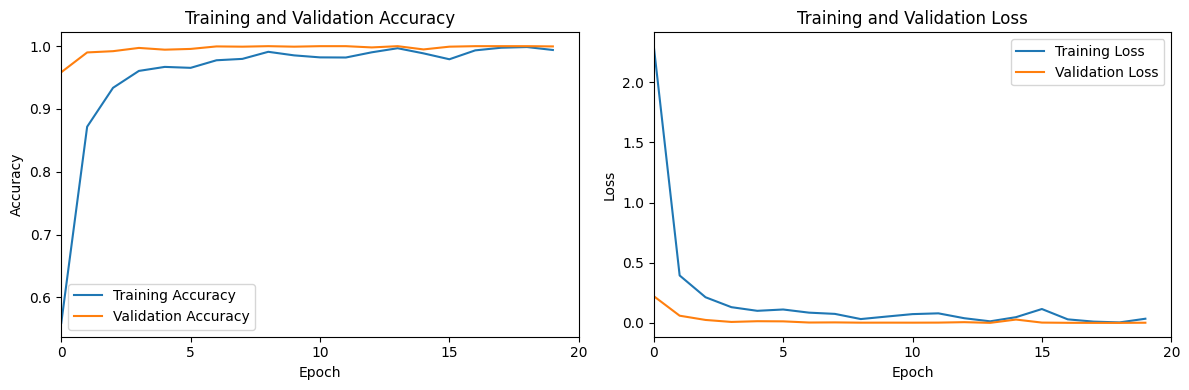

Visualizing some input data:


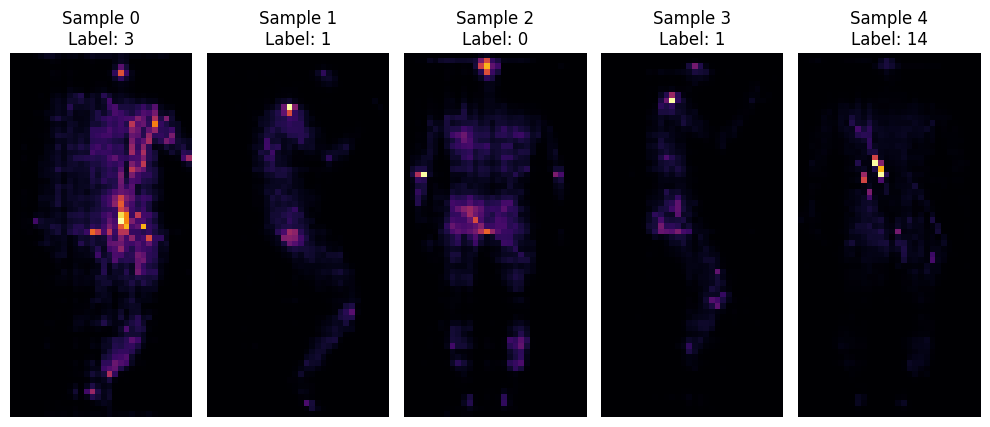

Visualizing some input data with real and predicted labels:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step


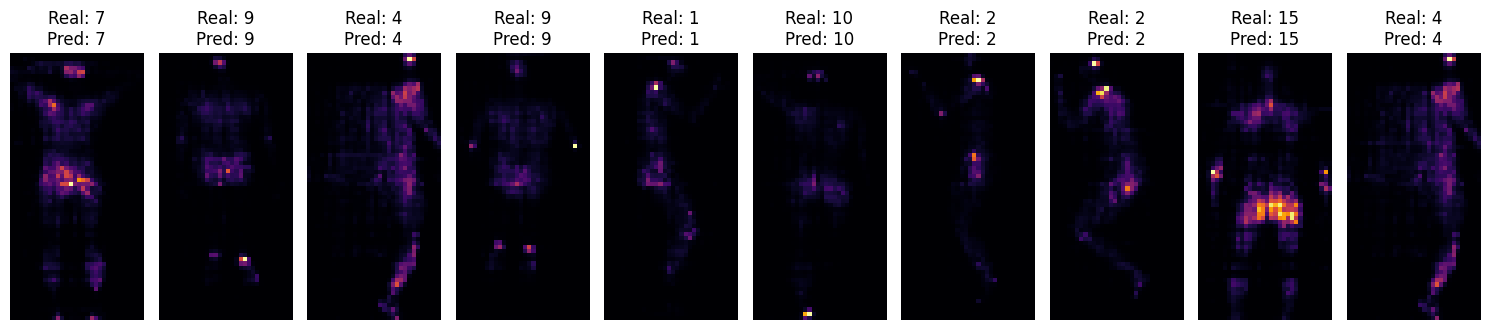

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 5))
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 5))
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

#visualize some of the input data
print("Visualizing some input data:")
plt.figure(figsize=(10, 5))
for i in range(min(5, X_train.shape[0])): # Visualize up to 5 samples
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i, :, :, 0], cmap='inferno')
    plt.title(f'Sample {i}\nLabel: {np.argmax(y_train[i])}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Visualize some input data with real and predicted labels
print("Visualizing some input data with real and predicted labels:")
plt.figure(figsize=(15, 5))

#first 10 samples from the test set
num_samples_to_visualize = min(10, X_test.shape[0])
selected_samples = X_test[:num_samples_to_visualize]
real_labels = np.argmax(y_test[:num_samples_to_visualize], axis=1)

#predictions for the selected samples
predictions = model_fi.predict(selected_samples)
predicted_labels = np.argmax(predictions, axis=1)

for i in range(num_samples_to_visualize):
    plt.subplot(1, num_samples_to_visualize, i + 1)
    plt.imshow(selected_samples[i, :, :, 0], cmap='inferno')
    plt.title(f'Real: {real_labels[i]}\nPred: {predicted_labels[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Number of misclassified samples in the test set: 4

Visualizing some misclassified samples:


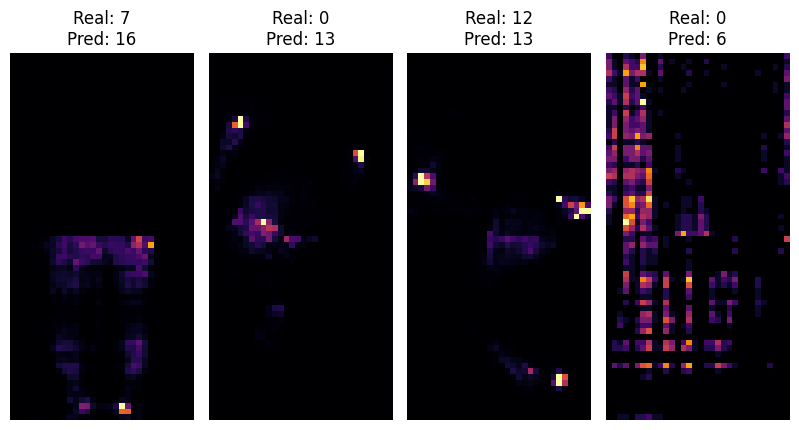

In [ ]:
y_pred = model_fi.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

misclassified_indices = np.where(y_pred_classes != y_true_classes)[0]

print(f"\nNumber of misclassified samples in the test set: {len(misclassified_indices)}")

#visualize some of the misclassified samples
if len(misclassified_indices) > 0:
    print("\nVisualizing some misclassified samples:")
    num_to_visualize = min(40, len(misclassified_indices)) # Visualize up to 40 misclassified samples

    # Calculate the number of rows and columns for subplots
    n_cols = 10
    n_rows = (num_to_visualize + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 2, n_rows * 5)) # Adjust figure size based on number of subplots

    for i in range(num_to_visualize):
        index_in_test_set = misclassified_indices[i]
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(X_test[index_in_test_set, :, :, 0], cmap='inferno')
        plt.title(f'Real: {y_true_classes[index_in_test_set]}\nPred: {y_pred_classes[index_in_test_set]}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
print(misclassified_indices)

[1150 1224 1377 2751]


123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9918    0.9959       244
           1     1.0000    1.0000    1.0000       231
           2     1.0000    1.0000    1.0000       239
           3     1.0000    1.0000    1.0000       208
           4     1.0000    1.0000    1.0000       252
           5     1.0000    1.0000    1.0000       221
           6     0.9961    1.0000    0.9980       255
           7     1.0000    0.9960    0.9980       247
           8     1.0000    1.0000    1.0000       230
           9     1.0000    1.0000    1.0000       248
          10     1.0000    1.0000    1.0000       230
          11     1.0000    1.0000    1.0000       219
          12     1.0000    0.9956    0.9978       228
          13     0.9916    1.0000    0.9958       237
          14     1.0000    1.0000    1.0000       213
          15     1.0000    1.0000    1.0000       212
          16     

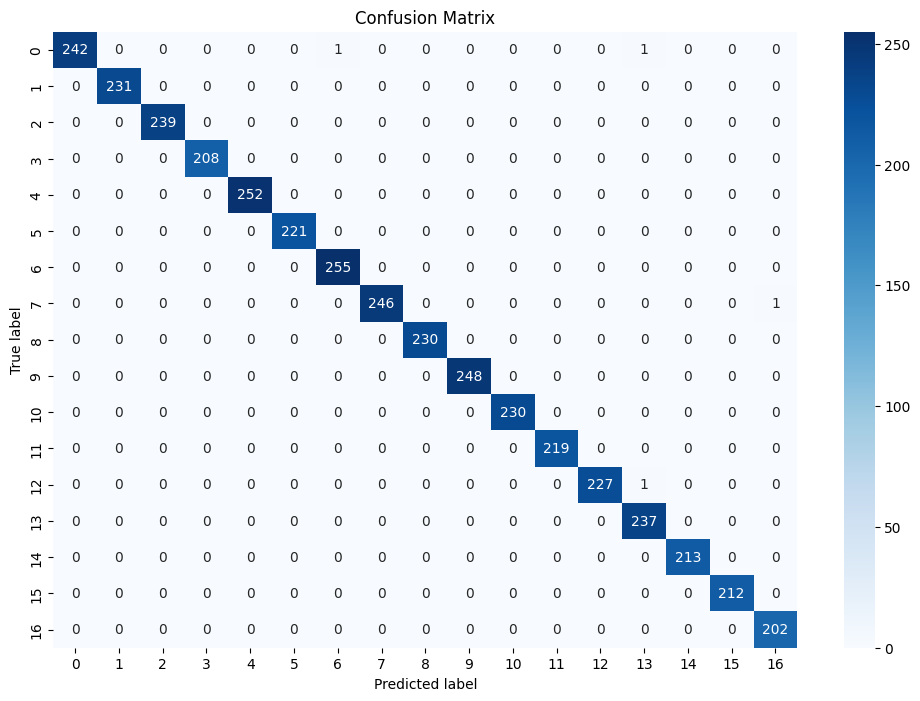

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ottieni le predizioni dal modello
y_pred_probs = model_fi.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, digits=4))
#macro	Media aritmetica: tutte le classi pesano uguale
#weighted	Media ponderata: tiene conto della distribuzione

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("posture_cnn_model_fi.h5")


## Grad-CAM

In [ ]:
# modello functional e non sequential perchè non riesco a far prendere la dimensione dell'input a grad_model
# quando creo gradcam-heatmap
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

inputs = Input(shape=(64, 32, 1))
x = Conv2D(32, (3, 3), activation='relu')(inputs)
x = MaxPooling2D((3, 3))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Architettura del modello:")
model.summary()

train_start_time = time.time()

# Train the model
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2, batch_size=32)

train_end_time = time.time()
training_time = train_end_time - train_start_time

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print(f"Training time: {training_time} seconds")


Architettura del modello:


Model: "functional_89"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 64, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 62, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 20, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 18, 8, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 9, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 3, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,145 (563.07 KB)

 Trainable params: 144,145 (563.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.2866 - loss: 7.0498 - val_accuracy: 0.9114 - val_loss: 0.4238
Epoch 2/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7213 - loss: 0.8049 - val_accuracy: 0.9653 - val_loss: 0.1725
Epoch 3/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8285 - loss: 0.4742 - val_accuracy: 0.9808 - val_loss: 0.0468
Epoch 4/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8812 - loss: 0.3344 - val_accuracy: 0.9681 - val_loss: 0.0802
Epoch 5/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9092 - loss: 0.2536 - val_accuracy: 0.9816 - val_loss: 0.0377
Epoch 6/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9298 - loss: 0.2223 - val_accuracy: 0.9920 - val_loss: 0.0286
Epoch 7/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9483 - loss: 0.1586 - val_accuracy: 0.9964 - val_loss: 0.0169
Epoch 8/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9498 - loss: 0.1605 - val_accuracy: 0

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Estraggo il layer convoluzionale desiderato
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # Costruisco un modello che restituisce le attivazioni del layer convoluzionale + output finale
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        # Eseguo il forward pass
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Calcolo i gradienti della classe target rispetto alle attivazioni convoluzionali
    grads = tape.gradient(class_channel, conv_outputs)

    # Media globale dei gradienti
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Moltiplico ogni feature map per la sua "importanza"
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalizzazione tra 0 e 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [ ]:

def display_gradcam(original_img, heatmap, alpha=0.3, cmap='Greens'):
    import matplotlib.pyplot as plt

    # Rimuovo l'ultimo asse se immagine in scala di grigi
    if original_img.shape[-1] == 1:
        original_img_display = original_img.squeeze()
    else:
        original_img_display = original_img

    # Inverto l'immagine: da bianco-su-nero a nero-su-bianco
    #inverted_img = 1000 - original_img_display

    # Normalizzo la heatmap se non già normalizzata
    heatmap = np.clip(heatmap, 0, 1)

    plt.figure(figsize=(8, 4))

    # Immagine originale
    plt.subplot(1, 3, 1)
    plt.title("Original Pressure Map")
    plt.imshow(original_img_display, cmap='gray')
    plt.axis('off')

    # Heatmap da sola
    plt.subplot(1, 3, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(heatmap, cmap=cmap)
    plt.axis('off')

    #Sovrapposizione (grayscale + heatmap trasparente)
    plt.subplot(1, 3, 3)
    plt.title("Overlay (Image + Heatmap)")
    plt.imshow(original_img_display, cmap='gray')
    plt.imshow(heatmap, cmap=cmap, alpha=alpha)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


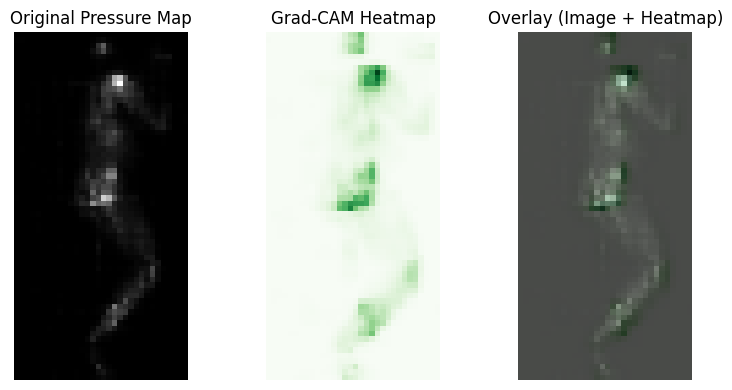

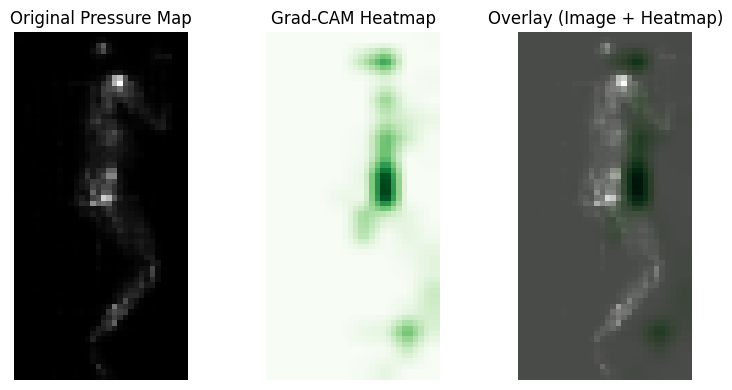

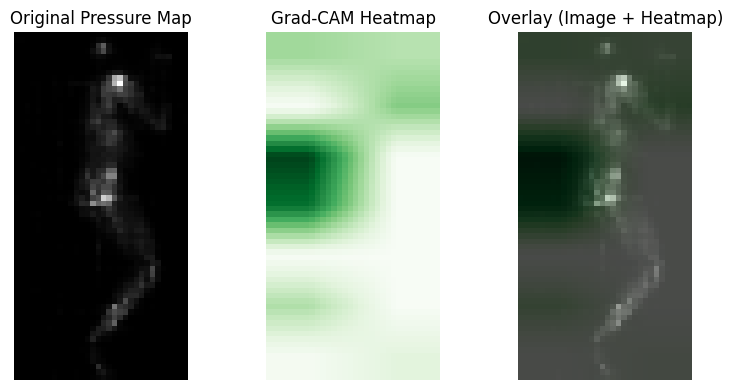

In [ ]:
# Scelgo un'immagine di test
i = 903  # indice dell'immagine da visualizzare
img = X_test[i]  # shape: (64, 32, 1)

input_img = np.expand_dims(img, axis=0)  # shape: (1, 64, 32, 1)

# Nome dell'ultimo layer convoluzionale
last_conv_layer_name = 'conv2d_23'
last_conv_layer_name_a = 'conv2d_22'
last_conv_layer_name_b = 'conv2d_21'

# Genera la heatmap Grad-CAM
heatmap = make_gradcam_heatmap(input_img, model, last_conv_layer_name)
heatmap_a = make_gradcam_heatmap(input_img, model, last_conv_layer_name_a)
heatmap_b = make_gradcam_heatmap(input_img, model, last_conv_layer_name_b)

# Resize heatmap to match input size
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_a_resized = cv2.resize(heatmap_a, (img.shape[1], img.shape[0]))
heatmap_b_resized = cv2.resize(heatmap_b, (img.shape[1], img.shape[0]))


# Mostra l'immagine con la heatmap
display_gradcam(img, heatmap_b_resized)
display_gradcam(img, heatmap_a_resized)
display_gradcam(img, heatmap_resized)

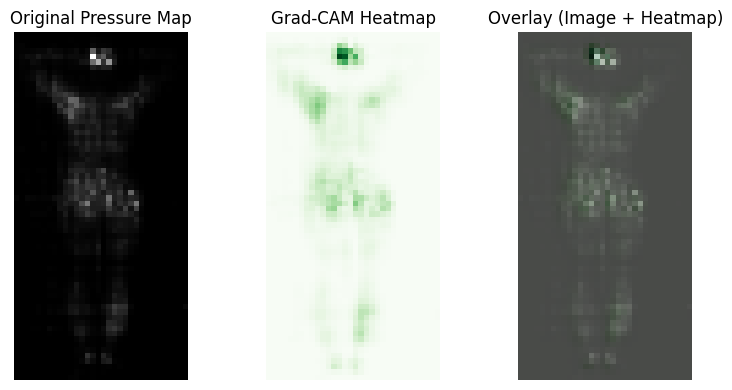

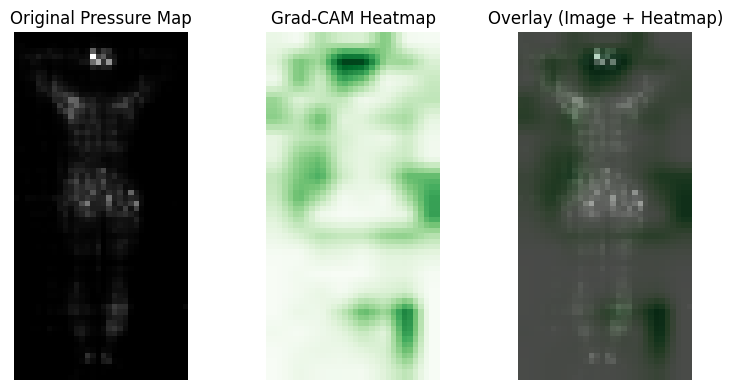

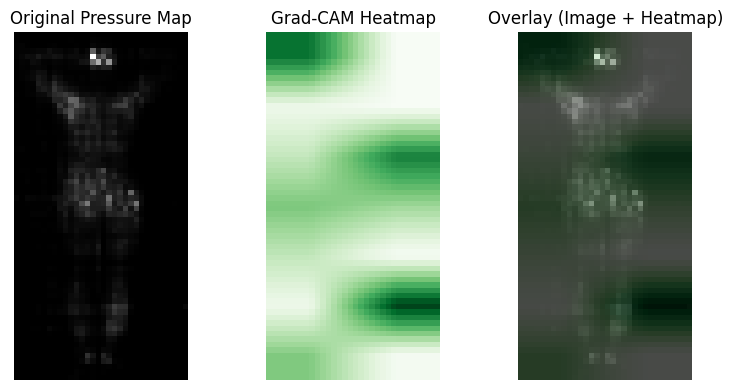

In [ ]:
# Scegli un'immagine di test
i = 905  # indice dell'immagine da visualizzare
img = X_test[i]  # shape: (64, 32, 1)

input_img = np.expand_dims(img, axis=0)  # shape: (1, 64, 32, 1)

# Nome dell'ultimo layer convoluzionale
last_conv_layer_name = 'conv2d_23'
last_conv_layer_name_a = 'conv2d_22'
last_conv_layer_name_b = 'conv2d_21'

# Genera la heatmap Grad-CAM
heatmap = make_gradcam_heatmap(input_img, model, last_conv_layer_name)
heatmap_a = make_gradcam_heatmap(input_img, model, last_conv_layer_name_a)
heatmap_b = make_gradcam_heatmap(input_img, model, last_conv_layer_name_b)

# Resize heatmap to match input size
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_a_resized = cv2.resize(heatmap_a, (img.shape[1], img.shape[0]))
heatmap_b_resized = cv2.resize(heatmap_b, (img.shape[1], img.shape[0]))


# Mostra l'immagine con la heatmap
display_gradcam(img, heatmap_b_resized)
display_gradcam(img, heatmap_a_resized)
display_gradcam(img, heatmap_resized)

## Demonstration

In [ ]:
class_names = {
    0: 'Supine',
    1: 'Right',
    2: 'Left',
    3: 'Right, body-roll 30°',
    4: 'Right, body-roll 60°',
    5: 'Left, body-roll 30°',
    6: 'Left, body-roll 60°',
    7: 'Supine, "star"',
    8: 'Supine, "straight"',
    9: 'Supine, "bent legs"',
    10: 'Supine, "left arm up"',
    11: 'Supine, "right arm up"',
    12: 'Right fetus',
    13: 'Left fetus',
    14: 'Supine, bed inclination 30°',
    15: 'Supine, bed inclination 45°',
    16: 'Supine, bed inclination 60°',
    17: 'Sensor detection error'
}

In [ ]:
import ipywidgets as widgets
from IPython.display import display

#load the model

def show_prediction(index):
    image = X_test[index]
    true_label = np.argmax(y_test[index])
    prediction = model_fi.predict(image[np.newaxis, ...])
    pred_label = np.argmax(prediction)

    plt.imshow(image[:, :, 0], cmap='inferno')
    plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
    plt.axis('off')
    plt.show()

slider = widgets.IntSlider(min=0, max=100, step=1, description='Index_image') #max=len(X_test)-1
widgets.interact(show_prediction, index=slider)

print('Data collected using Vista Medical FSA SoftFlex 2048')

#Right and left are the opposite in all dataset



interactive(children=(IntSlider(value=0, description='Index_image'), Output()), _dom_classes=('widget-interact…

Data collected using Vista Medical FSA SoftFlex 2048
